In [2]:
# Enterprise FinTech Payment Intelligence Platform
## Phase 4 – Machine Learning
### Notebook 02 – Exploratory Data Analysis

**Objective:**
Analyze transaction behavior, fraud distribution, numerical variables, and business patterns before feature engineering and model training.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("clean_ml_dataset.csv")
print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,TransactionID,DayNumber,HourOfSimulation,PeriodOfDay,TransactionType,SourceAccountID,DestinationAccountID,IsFraud,IsFlaggedFraud,Amount,OldBalanceOrig,NewBalanceOrig,OldBalanceDest,NewBalanceDest
0,20666,1,13,Afternoon,PAYMENT,C2108058134,M1963634359,False,False,22005.03,0.00,0.00,0.00,0.00
1,20851,1,15,Afternoon,CASH_IN,C1672847392,C882180306,False,False,214524.46,5030.00,219554.46,0.00,0.00
2,21169,1,15,Afternoon,TRANSFER,C519692057,C834458122,False,False,1432648.47,0.00,0.00,1453236.68,2885885.15
3,21181,1,15,Afternoon,CASH_OUT,C1634465843,C807329566,False,False,352807.10,0.00,0.00,426401.78,779208.88
4,21321,1,15,Afternoon,CASH_OUT,C210125456,C410910993,False,False,275348.64,390959.31,115610.67,0.00,275348.64


In [3]:
print("="*60)
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")
print("="*60)

Rows    : 6,362,620
Columns : 14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 14 columns):
 #   Column                Dtype  
---  ------                -----  
 0   TransactionID         int64  
 1   DayNumber             int64  
 2   HourOfSimulation      int64  
 3   PeriodOfDay           object 
 4   TransactionType       object 
 5   SourceAccountID       object 
 6   DestinationAccountID  object 
 7   IsFraud               bool   
 8   IsFlaggedFraud        bool   
 9   Amount                float64
 10  OldBalanceOrig        float64
 11  NewBalanceOrig        float64
 12  OldBalanceDest        float64
 13  NewBalanceDest        float64
dtypes: bool(2), float64(5), int64(3), object(4)
memory usage: 594.7+ MB


In [5]:
df.describe().apply(lambda s: s.apply('{0:.2f}'.format))

,TransactionID,DayNumber,HourOfSimulation,Amount,OldBalanceOrig,NewBalanceOrig,OldBalanceDest,NewBalanceDest
count,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00,6362620.00
mean,3181310.50,10.49,15.59,179861.90,833883.10,855113.67,1100701.67,1224996.40
std,1836730.33,5.92,4.10,603858.23,2888242.67,2924048.50,3399180.11,3674128.94
min,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,1590655.75,7.00,12.00,13389.57,0.00,0.00,0.00,0.00
50%,3181310.50,10.00,16.00,74871.94,14208.00,0.00,132705.66,214661.44
75%,4771965.25,14.00,19.00,208721.48,107315.18,144258.41,943036.71,1111909.25
max,6362620.00,31.00,24.00,92445516.64,59585040.37,49585040.37,356015889.35,356179278.92


In [6]:
## 1. Target Variable Analysis
fraud_counts = df["IsFraud"].value_counts()
fraud_percent = df["IsFraud"].value_counts(normalize=True) * 100

display(
    pd.DataFrame({
        "Count": fraud_counts,
        "Percentage": fraud_percent.round(3)
    })
)

,Count,Percentage
IsFraud,,
False,6354407,99.871
True,8213,0.129


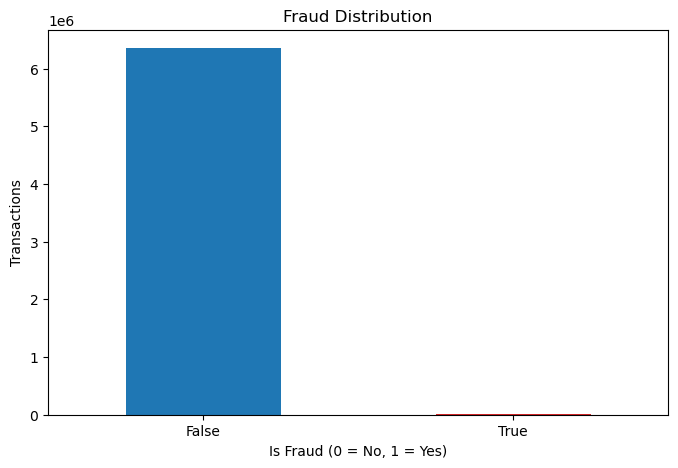

In [7]:
fraud_counts.plot(kind="bar", color=['#1f77b4', '#d62728'])
plt.title("Fraud Distribution")
plt.xlabel("Is Fraud (0 = No, 1 = Yes)")
plt.ylabel("Transactions")
plt.xticks(rotation=0)
plt.show()

In [ ]:
### 💡 Business Insight
* The dataset is extremely imbalanced.
* Only around 0.13% of all transactions are fraudulent.
* This confirms that techniques such as SMOTE will be required before training machine learning models.
    

In [8]:
## 2. Transaction Type Analysis
type_counts = df["TransactionType"].value_counts()
display(type_counts)

TransactionType
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

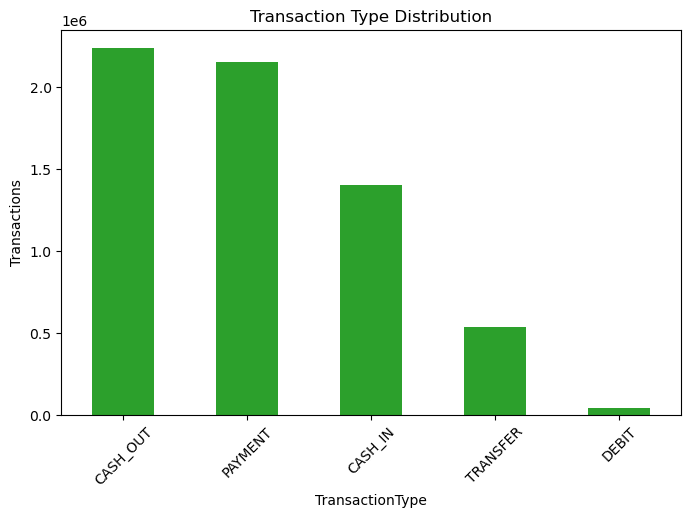

In [9]:
type_counts.plot(kind="bar", color='#2ca02c')
plt.title("Transaction Type Distribution")
plt.ylabel("Transactions")
plt.xticks(rotation=45)
plt.show()

In [ ]:
### 💡 Business Insight
* PAYMENT and CASH_OUT dominate transaction volume.
* DEBIT contributes only a very small percentage.
* Transaction behavior differs substantially by payment mechanism.

In [10]:
## 3. Fraud Pattern Analysis
fraud_by_type = (
    df.groupby("TransactionType")["IsFraud"]
    .sum()
    .sort_values(ascending=False)
)
display(fraud_by_type)

TransactionType
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: IsFraud, dtype: int64

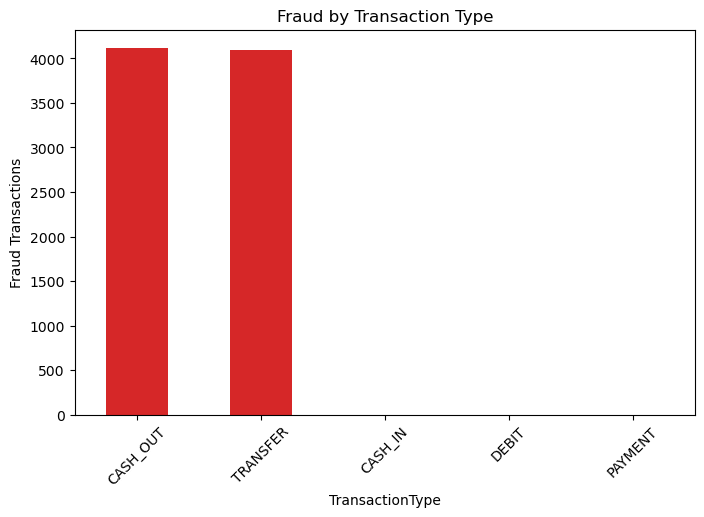

In [11]:
fraud_by_type.plot(kind="bar", color='#d62728')
plt.title("Fraud by Transaction Type")
plt.ylabel("Fraud Transactions")
plt.xticks(rotation=45)
plt.show()

In [ ]:
### 💡 Business Insight
* Fraud is concentrated almost entirely in TRANSFER and CASH_OUT transactions.
* This indicates attackers primarily exploit money movement mechanisms to extract funds.

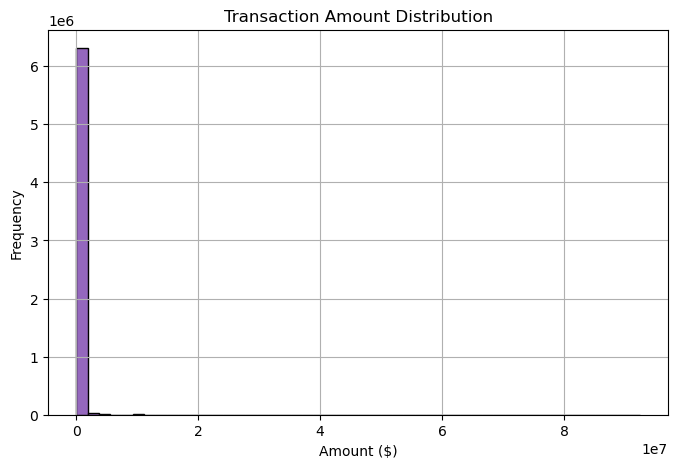

In [15]:
# 4. Amount Analysis
df["Amount"].hist(bins=50, color='#9467bd', edgecolor='black')
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount ($)")
plt.ylabel("Frequency")
plt.show()


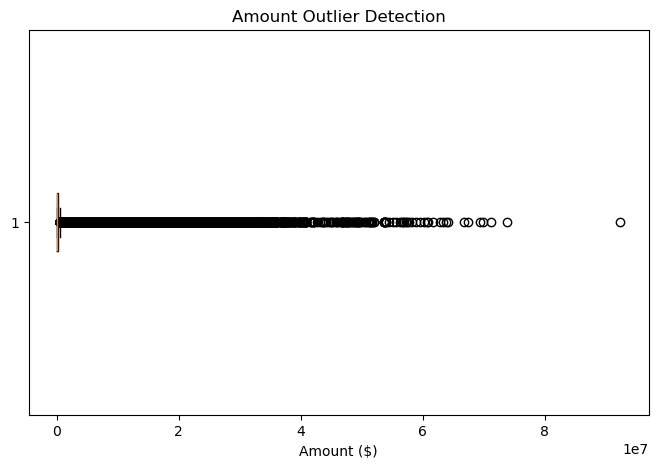

In [16]:
plt.boxplot(df["Amount"], vert=False)
plt.title("Amount Outlier Detection")
plt.xlabel("Amount ($)")
plt.show()

In [ ]:
### 💡 Business Insight
* Transaction amounts are highly right-skewed.
* Several extremely high-value transactions exist, which will require feature scaling (like StandardScaler) before modeling.

In [17]:
hourly = df.groupby("HourOfSimulation").size()
display(hourly.head())

HourOfSimulation
1    27111
2     9018
3     2007
4     1241
5     1641
dtype: int64

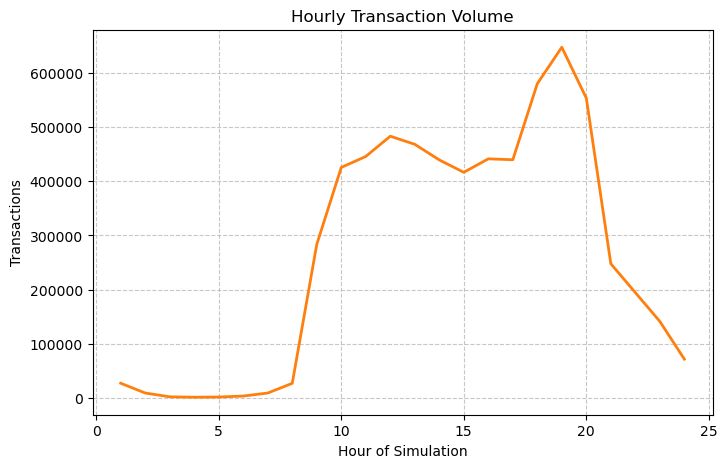

In [19]:
## 5. Time Analysis
hourly.plot(color='#ff7f0e', linewidth=2)
plt.title("Hourly Transaction Volume")
plt.xlabel("Hour of Simulation")
plt.ylabel("Transactions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
### 💡 Business Insight
* Transaction volume varies heavily across the simulated day.
* Peak activity periods can later become important predictive features for the model.

In [18]:
# Inspecting available numeric columns before feature engineering
numeric_cols = df.select_dtypes(include=["number", "bool"])
display(numeric_cols.head())

,TransactionID,DayNumber,HourOfSimulation,IsFraud,IsFlaggedFraud,Amount,OldBalanceOrig,NewBalanceOrig,OldBalanceDest,NewBalanceDest
0,20666,1,13,False,False,22005.03,0.00,0.00,0.00,0.00
1,20851,1,15,False,False,214524.46,5030.00,219554.46,0.00,0.00
2,21169,1,15,False,False,1432648.47,0.00,0.00,1453236.68,2885885.15
3,21181,1,15,False,False,352807.10,0.00,0.00,426401.78,779208.88
4,21321,1,15,False,False,275348.64,390959.31,115610.67,0.00,275348.64


In [ ]:
### 🎯 Final Business Summary

**Key Findings:**
* Dataset contains over 6.3 million payment transactions.
* Fraud represents approximately **0.13%** of all records, confirming severe class imbalance.
* `PAYMENT` and `CASH_OUT` dominate overall transaction volume.
* Fraud is strictly concentrated in `TRANSFER` and `CASH_OUT` transactions.
* Transaction amounts exhibit strong right-skewness with significant upper-bound outliers.
* Hourly transaction volume is highly cyclical, suggesting temporal behavior is a valid fraud indicator.
    The severe class imbalance justifies the use of SMOTE during model training.